# Random Forest IDPS Model - Iteration 2

## Objective
Drop identifier features that cause data leakage and retrain the model using only behavioral features.

## Changes from Iteration 1
- Remove non-behavioral columns: Timestamp, Flow ID, Src IP, Dst IP, Source Port, Dst Port, Unnamed: 0
- Keep only behavioral features (packet lengths, IATs, flow duration, header flags, packet rates, etc.)
- Add cross-validation for stability assessment
- Compare performance with Iteration 1


In [1]:
# === Imports ===
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve, average_precision_score, roc_auc_score
)
from sklearn.preprocessing import RobustScaler, label_binarize
import joblib
import yaml

# === Display & paths ===
sns.set_theme()
pd.set_option("display.max_columns", 120)

REPORTS_DIR = Path("../reports")
FIGS_DIR = REPORTS_DIR / "figs"
MODELS_DIR = Path("../models")
CONFIG_DIR = Path("../config")

for d in [REPORTS_DIR, FIGS_DIR, MODELS_DIR, CONFIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# === Training config ===
RANDOM_STATE = 42
TEST_SIZE = 0.30
TARGET_CANDIDATES = ["label","Label"," Label","class","Class","attack","Attack","target","Target"]

# Optional scaling (RF doesn't need scaling, but RobustScaler helps if features are very skewed)
APPLY_SCALING = False
ROBUST_SCALER_QR = (5.0, 95.0)  # quantile range for RobustScaler

# Cross-validation settings
CV_FOLDS = 5


In [2]:
# Load cleaned dataset
DATA_PATH = "../data/cleaned_cicddos2019_sample.csv"
df = pd.read_csv(DATA_PATH)
print(f"Original dataset shape: {df.shape}")
print(f"Original columns: {len(df.columns)}")
df.head(3)


Original dataset shape: (581613, 88)
Original columns: 88


,Unnamed: 0,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,SimillarHTTP,Inbound,Label
0,-0.818780,-0.022612,-0.084344,-0.599931,0.010236,1.461530,0.069283,-1.737906,-0.018015,0.223670,-0.027334,3.439851,-0.012137,-0.950231,-0.941322,-0.948191,-0.043051,-0.030924,-0.039058,-0.033481,-0.028521,-1.343403,-2.295521,-0.019654,-0.024833,-0.024820,-0.004979,-0.017067,-0.022439,-0.024722,-0.023853,-0.004920,-0.023911,-0.019751,-0.021141,-0.021584,-0.030684,-0.027795,0.0,0.0,0.0,0.062187,0.002622,-2.295272,-0.008046,-0.941295,-0.950482,-0.948911,-0.042613,-0.023269,0.0,-0.008894,-0.027795,0.0,-0.037391,-0.05731,-0.044394,0.0,-0.05716,-1.202411,-0.948191,-0.033481,0.062187,0.0,0.0,0.0,0.0,0.0,0.0,0.223670,3.439851,-0.027334,-0.012137,-0.035548,-0.025175,3.494683,0.275565,-0.011704,-0.004716,-0.008445,-0.011364,-0.024276,-0.008069,-0.024366,-0.023907,-0.014272,0.081031,-1.327339
1,-0.818706,-0.569552,10.814726,-0.599931,-14.299329,1.461530,0.069283,-1.737900,-0.029238,-0.013848,-0.027334,-0.231981,-0.012137,-0.950231,-0.941322,-0.948191,-0.043051,-0.030924,-0.039058,-0.033481,-0.028521,-0.953329,-0.843019,-0.021189,-0.026297,-0.027713,-0.004971,-0.028399,-0.023823,-0.026001,-0.026781,-0.004911,-0.023911,-0.019751,-0.021141,-0.021584,-0.030684,-0.027795,0.0,0.0,0.0,0.062187,0.002622,-0.842878,-0.008046,-0.941295,-0.950482,-0.948911,-0.042613,-0.023269,0.0,-0.008894,-0.027795,0.0,-0.037391,-0.05731,-0.044394,0.0,-0.05716,-0.937525,-0.948191,-0.033481,0.062187,0.0,0.0,0.0,0.0,0.0,0.0,-0.013848,-0.231981,-0.027334,-0.012137,-0.035548,-0.025175,-0.140838,0.275565,-0.011704,-0.004716,-0.008445,-0.011364,-0.024276,-0.008069,-0.024366,-0.023907,-0.014272,-12.340912,-1.327339
2,-0.800518,-0.037917,-0.084344,-0.599931,0.010236,0.719963,0.069283,-1.737894,-0.010061,0.481189,-0.027334,7.420890,-0.012137,-0.950231,-0.941322,-0.948191,-0.043051,-0.030924,-0.039058,-0.033481,-0.028521,-1.343127,-2.294493,-0.019926,-0.024608,-0.023353,-0.004979,-0.009037,-0.022684,-0.024526,-0.022369,-0.004920,-0.023911,-0.019751,-0.021141,-0.021584,-0.030684,-0.027795,0.0,0.0,0.0,0.062187,0.002622,-2.294243,-0.008046,-0.941295,-0.950482,-0.948911,-0.042613,-0.023269,0.0,-0.008894,-0.027795,0.0,-0.037391,-0.05731,-0.044394,0.0,-0.05716,-1.205283,-0.948191,-0.033481,0.062187,0.0,0.0,0.0,0.0,0.0,0.0,0.481189,7.420890,-0.027334,-0.012137,-0.035548,-0.025175,7.436353,0.275565,-0.011704,-0.004716,-0.008445,-0.011364,-0.024276,-0.008069,-0.024366,-0.023907,-0.014272,0.081031,-1.327339


In [3]:
# === STEP 1: Identify and Drop Identifier Features ===
# Define identifier columns that cause data leakage
IDENTIFIER_COLUMNS = [
    'Unnamed: 0',      # Index column
    'Flow ID',         # Unique flow identifier
    ' Source IP',      # Source IP address
    ' Source Port',    # Source port
    ' Destination IP', # Destination IP address
    ' Destination Port', # Destination port
    ' Timestamp',      # Timestamp information
]

print("Identifier columns to be removed:")
for col in IDENTIFIER_COLUMNS:
    if col in df.columns:
        print(f"  ✓ {col}")
    else:
        print(f"  ✗ {col} (not found)")

# Remove identifier columns
df_behavioral = df.drop(columns=[col for col in IDENTIFIER_COLUMNS if col in df.columns])

print(f"\nAfter removing identifier columns:")
print(f"Shape: {df_behavioral.shape}")
print(f"Remaining columns: {len(df_behavioral.columns)}")
print(f"Removed {df.shape[1] - df_behavioral.shape[1]} identifier columns")


Identifier columns to be removed:
  ✓ Unnamed: 0
  ✓ Flow ID
  ✓  Source IP
  ✓  Source Port
  ✓  Destination IP
  ✓  Destination Port
  ✓  Timestamp

After removing identifier columns:
Shape: (581613, 81)
Remaining columns: 81
Removed 7 identifier columns


In [4]:
# === STEP 2: Identify Target Column and Prepare Data ===
target_col = " Label"  # The actual column name with leading space
print("Target column:", target_col)

# Check target distribution
print("\nTarget class distribution:")
print(df_behavioral[target_col].value_counts().sort_index())

# Prepare features and target
X = df_behavioral.drop(columns=[target_col])
y = df_behavioral[target_col].astype(int)

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"Number of classes: {len(y.unique())}")


Target column:  Label

Target class distribution:
 Label
-2.216859      2985
-1.327339    142044
-0.437819    146149
 0.451701    146588
 1.341221    143847
Name: count, dtype: int64

Feature matrix shape: (581613, 80)
Target vector shape: (581613,)
Number of classes: 4


In [5]:
# === STEP 3: Train-Test Split ===
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

# Check class distribution in train/test sets
print("\nTraining set class distribution:")
print(y_train.value_counts().sort_index())
print("\nTest set class distribution:")
print(y_test.value_counts().sort_index())


Training set shape: (407129, 80)
Test set shape: (174484, 80)

Training set class distribution:
 Label
-2      2089
-1     99431
 0    204916
 1    100693
Name: count, dtype: int64

Test set class distribution:
 Label
-2      896
-1    42613
 0    87821
 1    43154
Name: count, dtype: int64


In [6]:
# === STEP 4: Data Preprocessing ===
# Coerce to numeric, set bad values to NaN
X_train = X_train.apply(pd.to_numeric, errors="coerce")
X_test = X_test.apply(pd.to_numeric, errors="coerce")

# Replace ±inf with NaN
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

# Check for missing values
print("Missing values in training set:")
missing_train = X_train.isnull().sum()
print(f"Columns with missing values: {(missing_train > 0).sum()}")
if (missing_train > 0).sum() > 0:
    print(missing_train[missing_train > 0])

print("\nMissing values in test set:")
missing_test = X_test.isnull().sum()
print(f"Columns with missing values: {(missing_test > 0).sum()}")
if (missing_test > 0).sum() > 0:
    print(missing_test[missing_test > 0])

# Median imputation (robust to skew)
imp = SimpleImputer(strategy="median")
X_train = pd.DataFrame(imp.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test = pd.DataFrame(imp.transform(X_test), columns=X.columns, index=X_test.index)

# Optional: Robust scaling (RF doesn't require it, but safe if you want)
if APPLY_SCALING:
    scaler = RobustScaler(quantile_range=ROBUST_SCALER_QR)
    num_cols = X_train.columns  # all are numeric now
    X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
    X_test[num_cols] = scaler.transform(X_test[num_cols])

print("\nPreprocessed shapes:", X_train.shape, X_test.shape)


Missing values in training set:
Columns with missing values: 0

Missing values in test set:
Columns with missing values: 0

Preprocessed shapes: (407129, 80) (174484, 80)


In [7]:
# === STEP 5: Train Random Forest Model ===
print("Training Random Forest model...")
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    n_jobs=-1,
    class_weight="balanced",   # helpful for class imbalance
    random_state=RANDOM_STATE
)

rf.fit(X_train, y_train)
print("Model training completed!")

# Get predictions and probabilities
pred_test = rf.predict(X_test)
proba_test = rf.predict_proba(X_test)

print(f"Prediction shape: {pred_test.shape}")
print(f"Probability shape: {proba_test.shape}")


Training Random Forest model...
Model training completed!
Prediction shape: (174484,)
Probability shape: (174484, 4)


In [8]:
# === STEP 6: Model Evaluation ===
# Calculate metrics
acc = accuracy_score(y_test, pred_test)
prec, rec, f1, _ = precision_recall_fscore_support(y_test, pred_test, average="weighted", zero_division=0)

print("=== Iteration 2 Results ===")
print(f"Accuracy: {acc:.4f}")
print(f"Weighted Precision: {prec:.4f}")
print(f"Weighted Recall: {rec:.4f}")
print(f"Weighted F1-score: {f1:.4f}")

# Detailed per-class performance
print("\n=== Per-Class Performance ===")
per_class_metrics = precision_recall_fscore_support(y_test, pred_test, average=None, zero_division=0)
classes = np.unique(y_test)

for i, cls in enumerate(classes):
    print(f"Class {cls}: Precision={per_class_metrics[0][i]:.3f}, Recall={per_class_metrics[1][i]:.3f}, F1={per_class_metrics[2][i]:.3f}")

# Classification report
print("\n=== Detailed Classification Report ===")
print(classification_report(y_test, pred_test, zero_division=0))


=== Iteration 2 Results ===
Accuracy: 0.7038
Weighted Precision: 0.7517
Weighted Recall: 0.7038
Weighted F1-score: 0.7004

=== Per-Class Performance ===
Class -2: Precision=0.997, Recall=0.996, F1=0.996
Class -1: Precision=0.526, Recall=0.866, F1=0.655
Class 0: Precision=0.829, Recall=0.528, F1=0.645
Class 1: Precision=0.813, Recall=0.895, F1=0.852

=== Detailed Classification Report ===
              precision    recall  f1-score   support

          -2       1.00      1.00      1.00       896
          -1       0.53      0.87      0.65     42613
           0       0.83      0.53      0.65     87821
           1       0.81      0.89      0.85     43154

    accuracy                           0.70    174484
   macro avg       0.79      0.82      0.79    174484
weighted avg       0.75      0.70      0.70    174484



In [9]:
# === STEP 7: Cross-Validation for Stability ===
print("Running 5-fold cross-validation...")

# Prepare full dataset for CV
X_full = X_train.copy()
y_full = y_train.copy()

# Cross-validation scores
cv_scores_accuracy = cross_val_score(rf, X_full, y_full, cv=CV_FOLDS, scoring='accuracy')
cv_scores_f1_weighted = cross_val_score(rf, X_full, y_full, cv=CV_FOLDS, scoring='f1_weighted')
cv_scores_recall_weighted = cross_val_score(rf, X_full, y_full, cv=CV_FOLDS, scoring='recall_weighted')
cv_scores_precision_weighted = cross_val_score(rf, X_full, y_full, cv=CV_FOLDS, scoring='precision_weighted')

print("=== Cross-Validation Results (5-fold) ===")
print(f"Accuracy:  {cv_scores_accuracy.mean():.4f} ± {cv_scores_accuracy.std():.4f}")
print(f"Precision: {cv_scores_precision_weighted.mean():.4f} ± {cv_scores_precision_weighted.std():.4f}")
print(f"Recall:    {cv_scores_recall_weighted.mean():.4f} ± {cv_scores_recall_weighted.std():.4f}")
print(f"F1-score:  {cv_scores_f1_weighted.mean():.4f} ± {cv_scores_f1_weighted.std():.4f}")

# Individual fold results
print("\n=== Individual Fold Results ===")
cv_results = pd.DataFrame({
    'Fold': range(1, CV_FOLDS + 1),
    'Accuracy': cv_scores_accuracy,
    'Precision': cv_scores_precision_weighted,
    'Recall': cv_scores_recall_weighted,
    'F1-Score': cv_scores_f1_weighted
})
print(cv_results.round(4))


Running 5-fold cross-validation...
=== Cross-Validation Results (5-fold) ===
Accuracy:  0.7071 ± 0.0012
Precision: 0.7535 ± 0.0010
Recall:    0.7071 ± 0.0012
F1-score:  0.7040 ± 0.0013

=== Individual Fold Results ===
   Fold  Accuracy  Precision  Recall  F1-Score
0     1    0.7083     0.7549  0.7083    0.7053
1     2    0.7080     0.7541  0.7080    0.7049
2     3    0.7076     0.7531  0.7076    0.7047
3     4    0.7068     0.7534  0.7068    0.7034
4     5    0.7049     0.7520  0.7049    0.7017


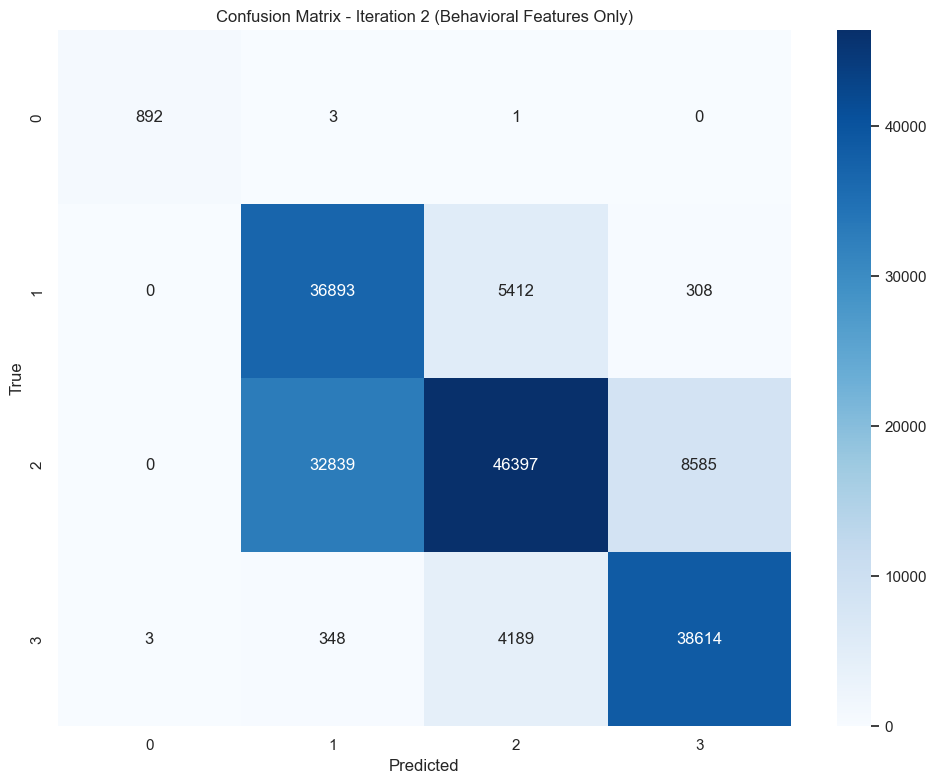

In [10]:
# === STEP 8: Confusion Matrix ===
cm = confusion_matrix(y_test, pred_test)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cbar=True, cmap='Blues')
plt.title("Confusion Matrix - Iteration 2 (Behavioral Features Only)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig(FIGS_DIR / "confusion_matrix_iteration2.png", dpi=120)
plt.show()


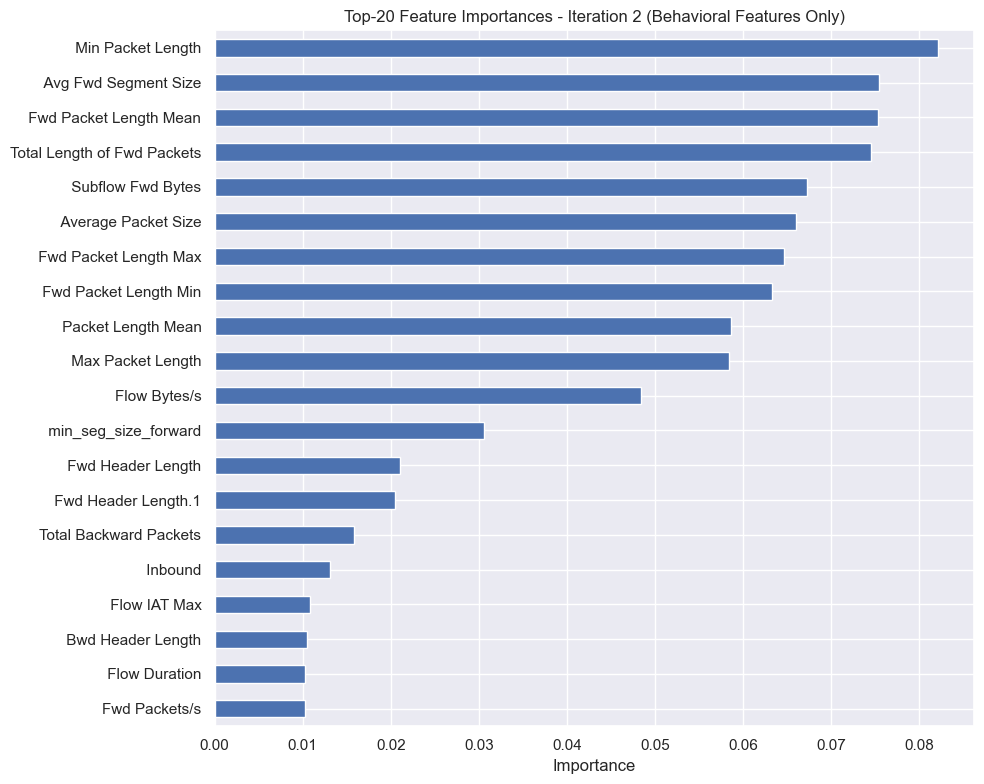

Top 10 Most Important Features:
 Min Packet Length             0.082098
 Avg Fwd Segment Size          0.075378
 Fwd Packet Length Mean        0.075351
Total Length of Fwd Packets    0.074495
 Subflow Fwd Bytes             0.067246
 Average Packet Size           0.065964
 Fwd Packet Length Max         0.064630
 Fwd Packet Length Min         0.063241
 Packet Length Mean            0.058674
 Max Packet Length             0.058359
dtype: float64


In [11]:
# === STEP 9: Feature Importance Analysis ===
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
top20 = importances.head(20)

plt.figure(figsize=(10, 8))
top20[::-1].plot(kind="barh")
plt.title("Top-20 Feature Importances - Iteration 2 (Behavioral Features Only)")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig(FIGS_DIR / "feature_importance_top20_iteration2.png", dpi=120)
plt.show()

print("Top 10 Most Important Features:")
print(top20.head(10))

# Save feature importance to CSV
top20.to_csv(REPORTS_DIR / "feature_importance_top20_iteration2.csv")


In [12]:
# === STEP 10: Save Model and Results ===
# Save model
model_path = MODELS_DIR / "rf_multiclass_iteration2.pkl"
joblib.dump(rf, model_path)

# Save config for serving
config = {
    "model_path": str(model_path),
    "feature_columns": list(X.columns),
    "target": target_col,
    "classes": [int(cls) for cls in np.unique(y)],
    "removed_identifier_columns": [col for col in IDENTIFIER_COLUMNS if col in df.columns],
    "notes": "RandomForest (multiclass, iteration2), behavioral features only, class_weight=balanced, median-imputed, "
             + ("robust-scaled" if APPLY_SCALING else "no-scaling")
}
with open(CONFIG_DIR / "model_config_iteration2.yaml", "w") as f:
    yaml.safe_dump(config, f)

# Save comprehensive metrics
metrics = {
    "iteration": 2,
    "description": "Behavioral features only (identifier features removed)",
    "data_info": {
        "original_shape": list(df.shape),
        "final_shape": list(df_behavioral.shape),
        "removed_columns": len(df.columns) - len(df_behavioral.columns),
        "n_features_used": len(X.columns)
    },
    "performance": {
        "accuracy": float(acc),
        "weighted_precision": float(prec),
        "weighted_recall": float(rec),
        "weighted_f1": float(f1)
    },
    "cross_validation": {
        "cv_folds": CV_FOLDS,
        "accuracy_mean": float(cv_scores_accuracy.mean()),
        "accuracy_std": float(cv_scores_accuracy.std()),
        "f1_mean": float(cv_scores_f1_weighted.mean()),
        "f1_std": float(cv_scores_f1_weighted.std()),
        "recall_mean": float(cv_scores_recall_weighted.mean()),
        "recall_std": float(cv_scores_recall_weighted.std()),
        "precision_mean": float(cv_scores_precision_weighted.mean()),
        "precision_std": float(cv_scores_precision_weighted.std())
    }
}

with open(REPORTS_DIR / "metrics_iteration2.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("=== Model and Results Saved ===")
print(f"Model saved to: {model_path}")
print(f"Config saved to: {CONFIG_DIR / 'model_config_iteration2.yaml'}")
print(f"Metrics saved to: {REPORTS_DIR / 'metrics_iteration2.json'}")
print(f"Figures saved to: {FIGS_DIR}")


=== Model and Results Saved ===
Model saved to: ..\models\rf_multiclass_iteration2.pkl
Config saved to: ..\config\model_config_iteration2.yaml
Metrics saved to: ..\reports\metrics_iteration2.json
Figures saved to: ..\reports\figs


In [13]:
# === STEP 11: Comparison with Iteration 1 ===
# Load Iteration 1 metrics if available
iteration1_metrics_path = REPORTS_DIR / "metrics.json"

if iteration1_metrics_path.exists():
    with open(iteration1_metrics_path, 'r') as f:
        iteration1_metrics = json.load(f)
    
    print("=== Performance Comparison: Iteration 1 vs Iteration 2 ===")
    print(f"{'Metric':<20} {'Iteration 1':<15} {'Iteration 2':<15} {'Difference':<15}")
    print("-" * 65)
    
    # Compare key metrics
    metrics_to_compare = ['accuracy', 'weighted_precision', 'weighted_recall', 'weighted_f1']
    
    for metric in metrics_to_compare:
        iter1_val = iteration1_metrics.get(metric, 0)
        iter2_val = metrics['performance'][metric]
        diff = iter2_val - iter1_val
        
        print(f"{metric:<20} {iter1_val:<15.4f} {iter2_val:<15.4f} {diff:+.4f}")
    
    print("\n=== Analysis ===")
    if metrics['performance']['accuracy'] < iteration1_metrics.get('accuracy', 1):
        print("✓ Expected: Accuracy decreased after removing identifier features")
        print("  This indicates the model was previously relying on data leakage")
    else:
        print("⚠ Unexpected: Accuracy increased or stayed the same")
        print("  This might indicate the identifier features were not causing leakage")
    
    print(f"\n✓ Model now uses only {metrics['data_info']['n_features_used']} behavioral features")
    print(f"✓ Removed {metrics['data_info']['removed_columns']} identifier columns")
    print(f"✓ Cross-validation shows stability: F1 = {cv_scores_f1_weighted.mean():.4f} ± {cv_scores_f1_weighted.std():.4f}")
    
else:
    print("Iteration 1 metrics not found. Run Iteration 1 first for comparison.")
    print("\n=== Current Iteration 2 Results ===")
    print(f"Accuracy: {acc:.4f}")
    print(f"Weighted F1: {f1:.4f}")
    print(f"Cross-validation F1: {cv_scores_f1_weighted.mean():.4f} ± {cv_scores_f1_weighted.std():.4f}")


Iteration 1 metrics not found. Run Iteration 1 first for comparison.

=== Current Iteration 2 Results ===
Accuracy: 0.7038
Weighted F1: 0.7004
Cross-validation F1: 0.7040 ± 0.0013


In [14]:
# === STEP 12: Sample Predictions ===
# Test model predictions on a sample
sample = X_test.iloc[:5].copy()
predictions = rf.predict(sample)
probabilities = rf.predict_proba(sample)

# Get the class names
classes = np.unique(y)
class_names = [f"Class_{cls}" for cls in classes]

# Create a results dataframe
results_df = pd.DataFrame({
    "Predicted_Class": predictions,
    "True_Class": y_test.iloc[:5].values
})

# Add probability scores for each class
for i, class_name in enumerate(class_names):
    results_df[f"Prob_{class_name}"] = probabilities[:, i]

print("=== Sample Predictions (Iteration 2) ===")
print(results_df)

# Show prediction accuracy for this sample
correct_predictions = (predictions == y_test.iloc[:5].values).sum()
print(f"\nSample accuracy: {correct_predictions}/5 = {correct_predictions/5:.2%}")


=== Sample Predictions (Iteration 2) ===
   Predicted_Class  True_Class  Prob_Class_-2  Prob_Class_-1  Prob_Class_0  \
0                0           1            0.0       0.000000      0.852916   
1               -1          -1            0.0       1.000000      0.000000   
2               -1           0            0.0       0.555479      0.409409   
3               -1           0            0.0       0.544980      0.445200   
4                0           0            0.0       0.371255      0.625794   

   Prob_Class_1  
0      0.147084  
1      0.000000  
2      0.035112  
3      0.009820  
4      0.002951  

Sample accuracy: 2/5 = 40.00%
